# N$_2$O - calculate global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_n2o_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "only"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "only"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

In [9]:
config_step.observational_network_latitudinal_gradient_eofs_file

PosixPath('/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/data/interim/n2o/n2o_observational-network_latitudinal-gradient-eofs.nc')

In [10]:
config_step.observational_network_seasonality_file

PosixPath('/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/data/interim/n2o/n2o_observational-network_seasonality.nc')

In [11]:
config_step.observational_network_global_annual_mean_file

PosixPath('/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/data/interim/n2o/n2o_observational-network_global-annual-mean.nc')

## Action

### Load data

In [7]:
interpolated_spatial = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[306.641 306.087 305.53299999999996 ... 307.946 308.017 308.582] [306.641 306.087 305.9403636363636 ... 307.75733333333335 308.16966666666667 308.582] [306.641 306.29068181818184 306.49323076923076 ... 305.355 307.085 308.582] [306.641 306.5564666666667 306.4719333333333 ... 305.9326296296297 307.31800000000004 308.582] [306.641 306.087 305.76773333333335 ... 306.51025925925927 307.551 308.582] [306.641 306.087 305.533 ... 307.08788888888887 307.784 308.582]] [[306.356 305.93566666666663 305.51533333333333 ... 308.021 308.021 308.441] [306.356 305.93566666666663 305.97172727272726 ... 307.42633333333333 307.9336666666666 308.441] [306.356 306.16386363636366 306.49115384615385 ... 304.908 306.8241111111111 308.441] [306.356 306.2883333333333 306.22066666666666 ... 305.6067037037037 307.12333333333333 308.441] [306.356 305.93566666666663 305.69166666666666 ... 306.3054074074074 307.42255555555556 308.441] [306.356 305.9356666666667 305.51533333333333 ... 307.0041111111111 307.7217777777778 308.441]] [[306.152 305.832 305.512 ... 308.161 307.976 308.332] [306.152 305.832 305.93399999999997 ... 307.25066666666663 307.79133333333334 308.332] [306.152 306.043 306.4052307692308 ... 305.335 306.9604444444444 308.332] [306.152 306.1424 306.1328 ... 305.91659259259256 307.21433333333334 308.332] [306.152 305.832 305.6672 ... 306.49818518518515 307.4682222222222 308.332] [306.152 305.832 305.512 ... 307.07977777777774 307.7221111111111 308.332]] ... [[336.231 336.35490000000004 336.4785 ... 337.251 336.961 336.99] [336.231 336.355 336.53785714285715 ... 337.42 337.205 336.99] [336.231 336.4513636363637 336.7680909090909 ... 337.32550000000003 337.13588888888887 336.99] [336.231 336.49626666666666 336.7615333333333 ... 337.21770370370376 337.0921666666667 336.99] [336.231 336.3547 336.5491333333333 ... 337.10990740740743 337.04844444444444 336.99] [336.231 336.3548 336.47839999999997 ... 337.0021111111111 337.0047222222222 336.99]] [[336.402 336.5239 336.6515 ... 337.572 337.41 337.332] [336.402 336.522 336.6972857142857 ... 337.61 337.471 337.332] [336.402 336.6153636363636 336.9220909090909 ... 337.595 337.45755555555553 337.332] [336.402 336.6602 336.9184 ... 337.5237407407408 337.4456666666667 337.332] [336.402 336.5277 336.7206 ... 337.45248148148147 337.4337777777778 337.332] [336.402 336.5258 336.65340000000003 ... 337.3812222222222 337.42188888888893 337.332]] [[336.693 336.7613333333333 336.82966666666664 ... 337.75 337.696 337.615] [336.693 336.7613333333333 336.8422727272727 ... 337.791 337.70300000000003 337.615] [336.693 336.76763636363637 336.9526153846154 ... 337.964 337.7791111111111 337.615] [336.693 336.93746666666664 337.18193333333335 ... 337.864962962963 337.7583333333334 337.615] [336.693 336.7613333333333 336.9177333333334 ... 337.76592592592596 337.73755555555556 337.615] [336.693 336.76133333333337 336.82966666666664 ... 337.6668888888889 337.71677777777785 337.615]]]
Units,ppb


### Drop out any years that have nan

These break everything later on

In [8]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    local.xarray_time.convert_time_to_year_month(interpolated_spatial).dropna("year")
)

### Longitudinal-mean

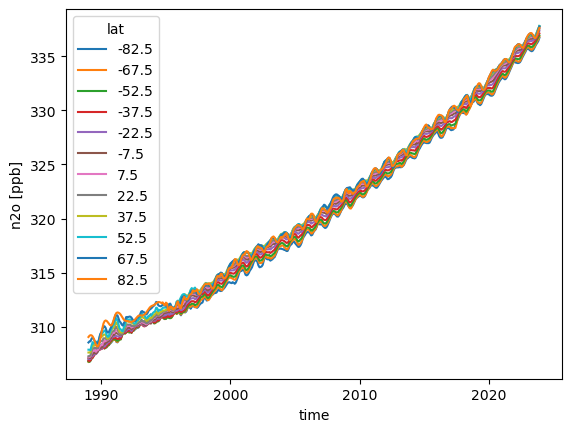

In [9]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")

### Global-, annual-mean

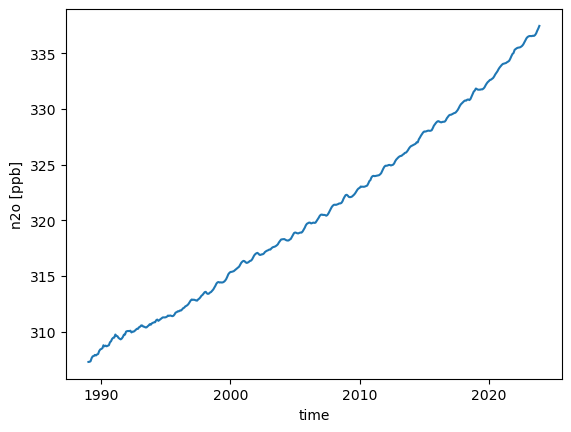

In [10]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

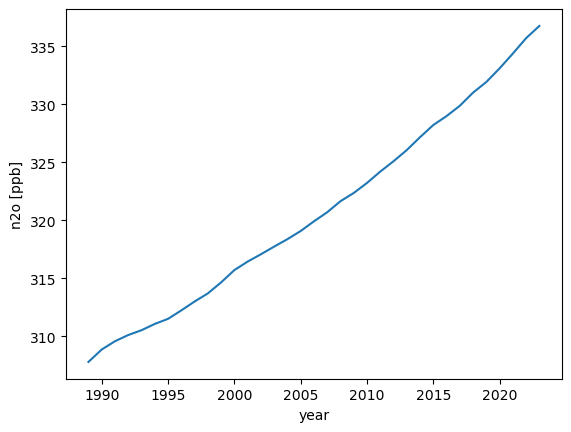

In [11]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [12]:
(
    lat_residuals_annual_mean,
    full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
full_eofs_pcs

<xarray.Dataset> Size: 5kB
Dimensions:               (lat: 12, eof: 12, year: 35)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 280B 1989 1990 1991 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppb] 0.5369 ... -0.05329
    principal-components  (year, eof) float64 3kB [] -1.268 1.24 ... 4.505e-14

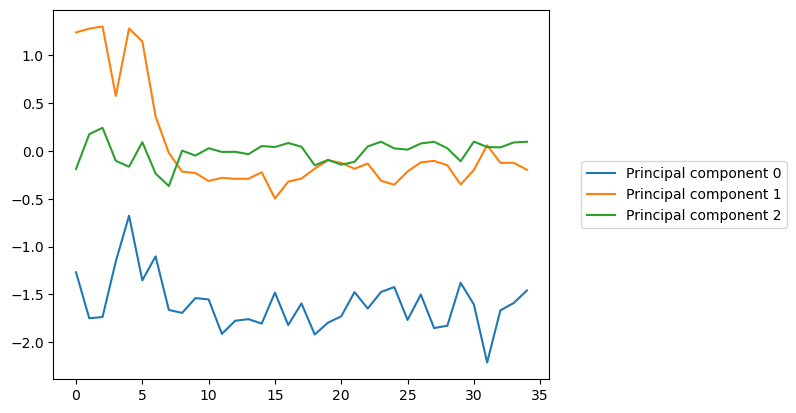

In [13]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )
    if i > 3:  # noqa: PLR2004
        break

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

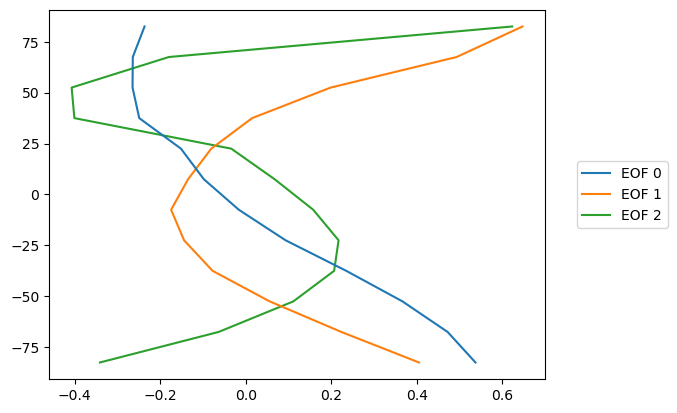

In [14]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        full_eofs_pcs["eofs"].sel(eof=i).data.m,
        full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

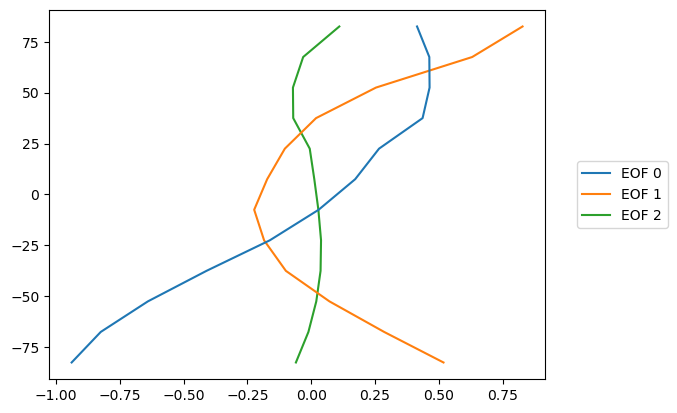

In [15]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1) @ full_eofs_pcs["eofs"].sel(eof=i),
        full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [16]:
eofs_pcs = full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
eofs_pcs

Magnitude,[[0.5368855977658882 0.404883433188743] [0.4716835589818648 0.22314685591708858] [0.36611165393917133 0.05565966859258745] [0.23470590918178547 -0.07782449131935192] [0.09286132125573 -0.1445171153065969] [-0.016499200333717906 -0.17485042508016524] [-0.09835066255332599 -0.13512732523865095] [-0.15181420783270086 -0.08095764201367836] [-0.24938031808131553 0.014616912347332653] [-0.26504377932629514 0.19819135432769625] [-0.2644629261443599 0.4927290198125983] [-0.23695701236836317 0.6469725499977116]]
Units,ppb
Magnitude,[[-1.2682318294927521 1.239646482942318] [-1.748890927061751 1.2795256531537198] [-1.7354957102799493 1.3021419593975372] [-1.154433393924311 0.575229414509505] [-0.6763202240515906 1.281043562578116] [-1.3527565253793667 1.1453972023874592] [-1.1014079524828708 0.36159440432620826] [-1.6616159383181697 -0.020019518710145352] [-1.693046919572638 -0.2159339199568484] [-1.5382982131218987 -0.22998779378412795] [-1.5516943252026723 -0.3131895616095386] [-1.9121090155353258 -0.2805865562980555] [-1.7749316498423109 -0.29059511929097437] [-1.757787727609693 -0.2901629599309715] [-1.804951505152692 -0.22222308105900831] [-1.4801171596489282 -0.4970286996202276] [-1.8198899788202918 -0.32054972488357336] [-1.5938993966548851 -0.2880686260158337] [-1.9187150908562858 -0.18408297476127838] [-1.7951034478941006 -0.0975297365431475] [-1.7282351419895083 -0.12367667662145491] [-1.475527223026247 -0.1856698816098967] [-1.6470390081169504 -0.13079050854763793] [-1.4740571193327112 -0.31138512824160297] [-1.4227154340827775 -0.35278637240359023] [-1.7662476203828705 -0.21405113325022723] [-1.5006387081910448 -0.11855862784430726] [-1.8514657034178048 -0.10326261286961627] [-1.8264901936322104 -0.149140017562873] [-1.3777184888868055 -0.35031237443430757] [-1.6048773489766508 -0.1985449260341904] [-2.2111598803132066 0.06049493978902651] [-1.6659073455562696 -0.1240566096158729] [-1.590186366329138 -0.12314976773438692] [-1.4581088361679806 -0.196013331831952]]
Units,dimensionless


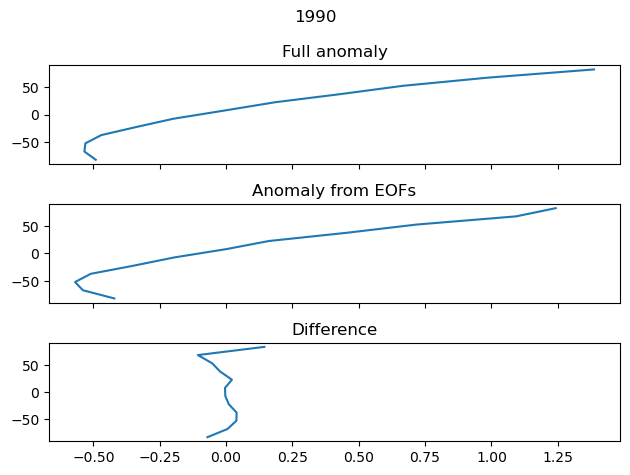

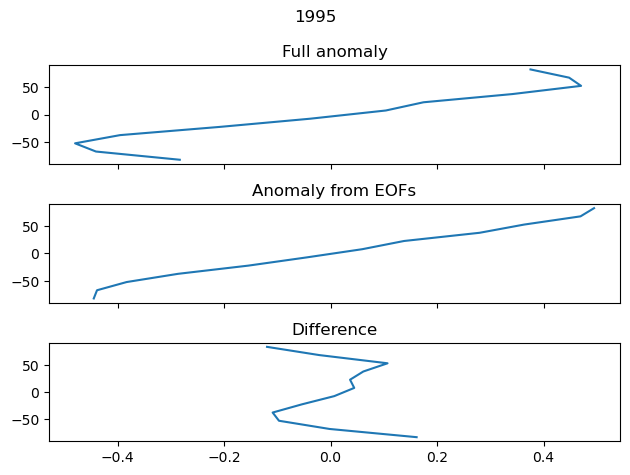

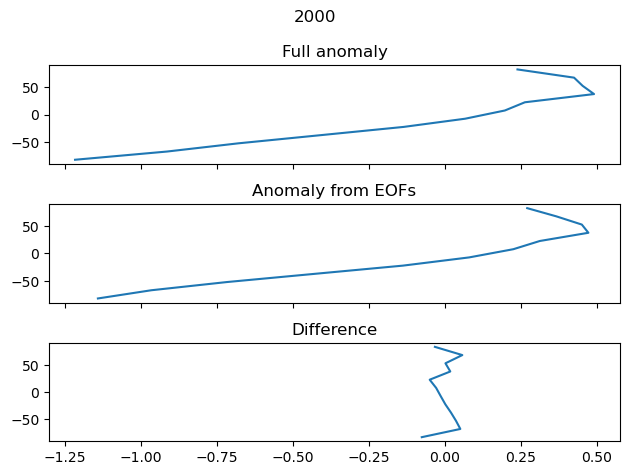

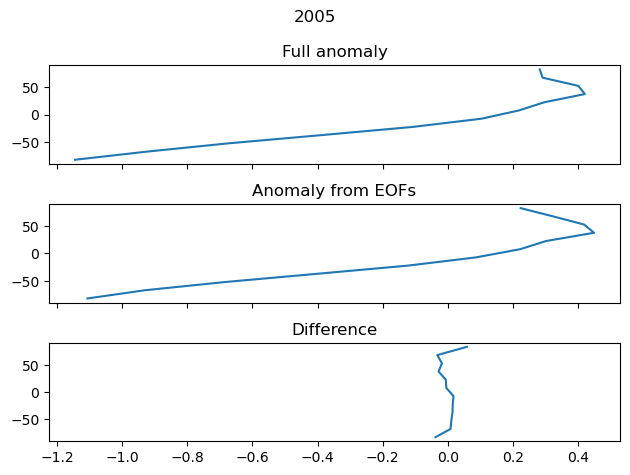

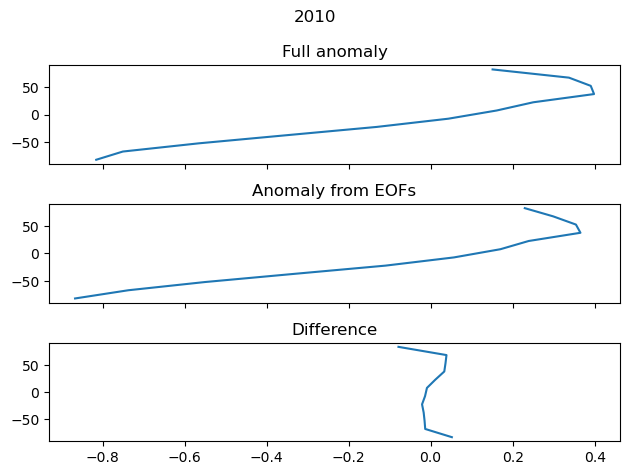

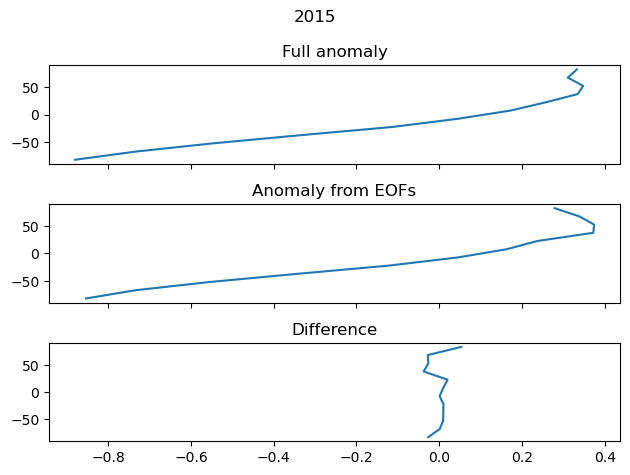

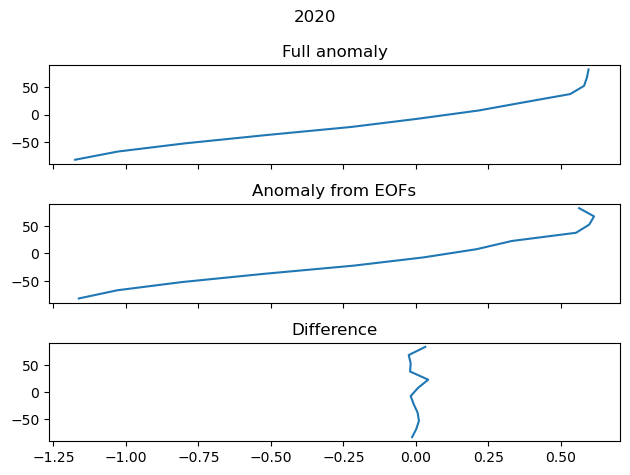

In [17]:
latitudinal_anomaly_from_eofs = eofs_pcs["principal-components"] @ eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [18]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/420 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [00:00<00:00, 14800.81it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/420 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/420 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [00:00<00:00, 19875.98it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/420 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 420/420 [00:00<00:00, 19230.06it/s]

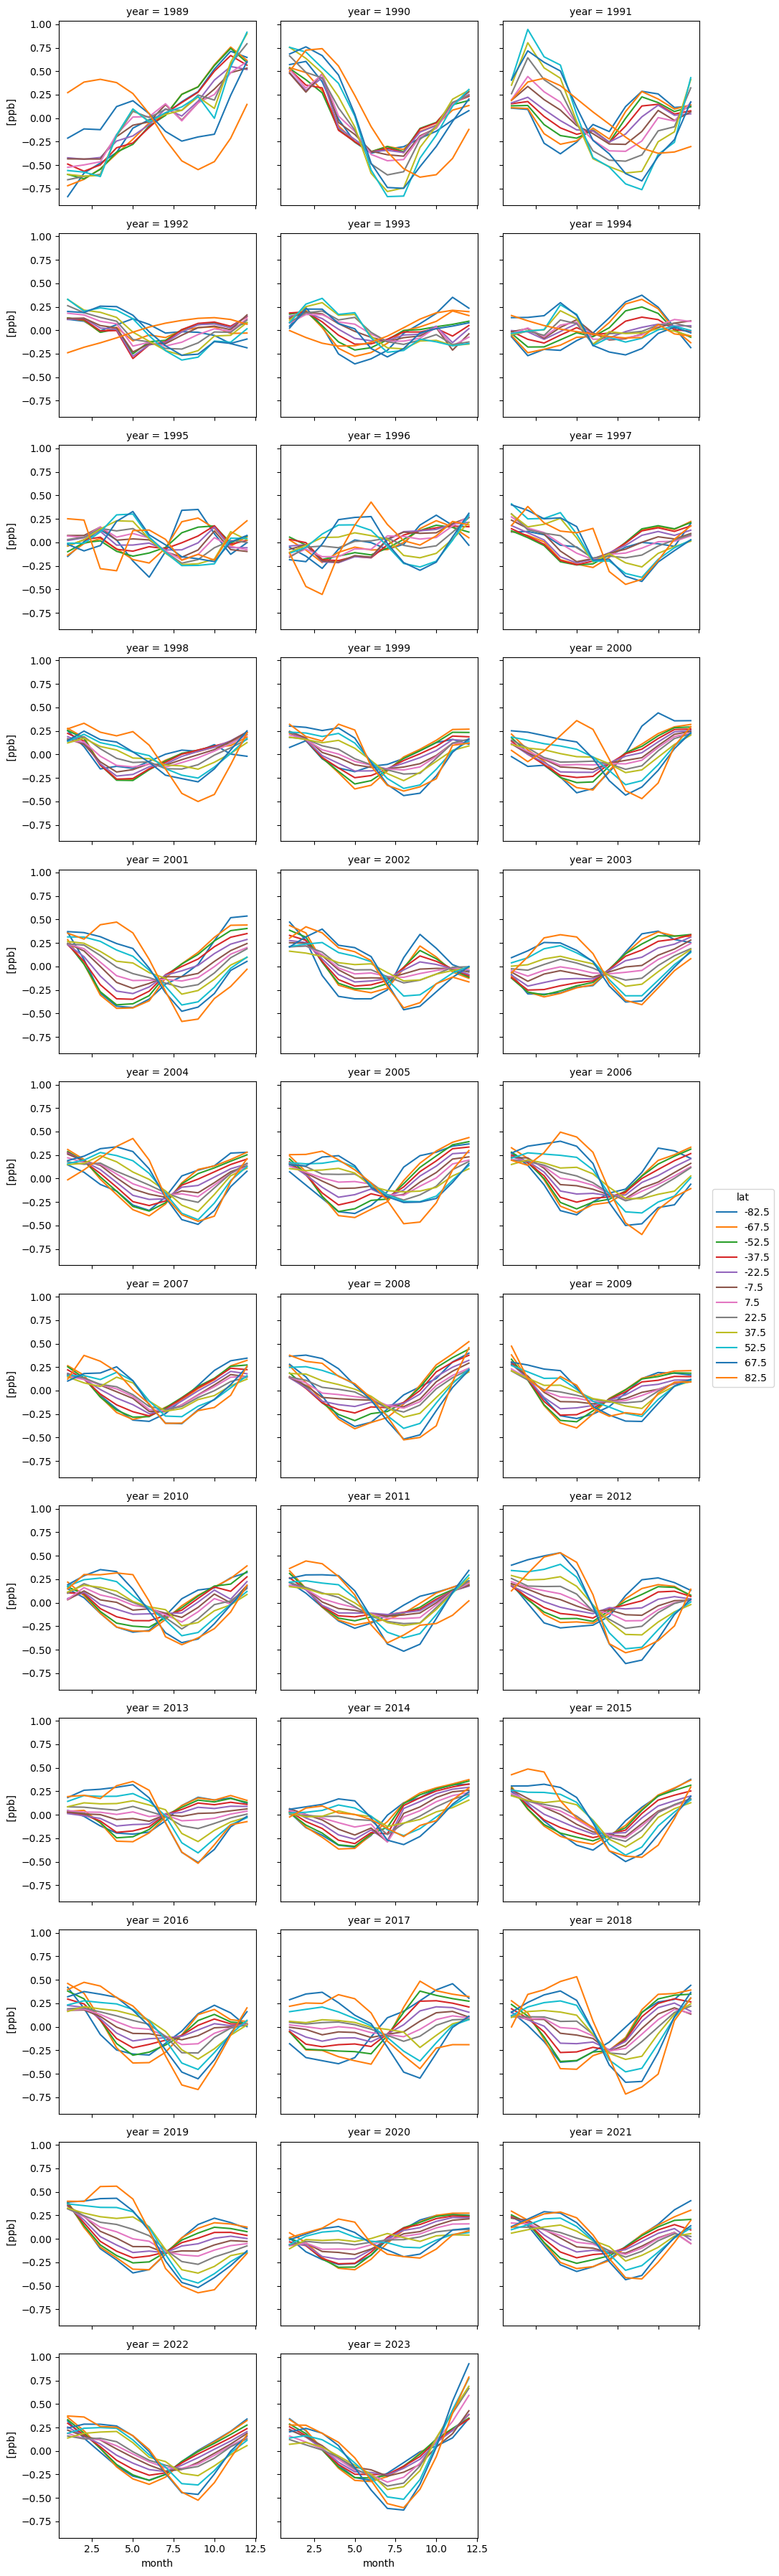

In [19]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

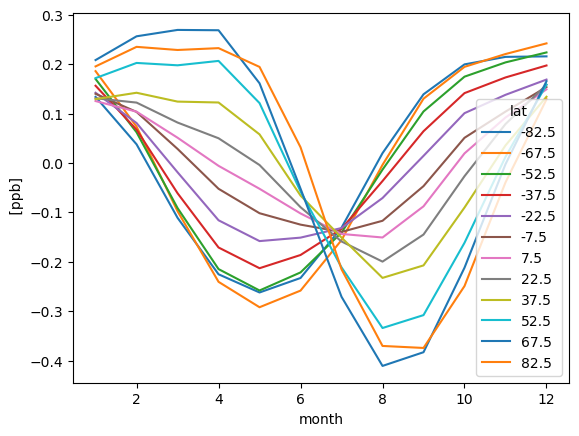

In [20]:
seasonality.plot.line(hue="lat")

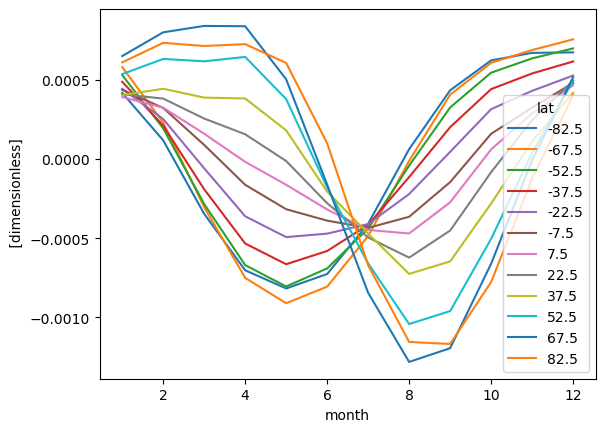

In [21]:
relative_seasonality.plot.line(hue="lat")

### Save

In [22]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[307.789469471156 308.8588121371664 309.573231166248 310.1066650538122 310.52220779068773 311.0628375887226 311.5015680266542 312.22944205629216 312.99383969307405 313.69241888618564 314.64130476711586 315.70067789980294 316.4348016752957 317.06460532844693 317.72533569674994 318.36731654780493 319.07036154102707 319.9035029124892 320.6853059740757 321.63848169942224 322.3469344513772 323.21054744312244 324.1900642984233 325.08177457373995 326.04431679707113 327.1559101387617 328.2021192828868 328.9748094139558 329.8620759099643 330.99757606841507 331.91387289475307 333.0865565697381 334.364730429223 335.6916614172983 336.74718785488454]
Units,ppb


In [23]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
eofs_pcs.pint.dequantify().to_netcdf(config_step.observational_network_latitudinal_gradient_eofs_file)
eofs_pcs

Magnitude,[[0.5368855977658882 0.404883433188743] [0.4716835589818648 0.22314685591708858] [0.36611165393917133 0.05565966859258745] [0.23470590918178547 -0.07782449131935192] [0.09286132125573 -0.1445171153065969] [-0.016499200333717906 -0.17485042508016524] [-0.09835066255332599 -0.13512732523865095] [-0.15181420783270086 -0.08095764201367836] [-0.24938031808131553 0.014616912347332653] [-0.26504377932629514 0.19819135432769625] [-0.2644629261443599 0.4927290198125983] [-0.23695701236836317 0.6469725499977116]]
Units,ppb
Magnitude,[[-1.2682318294927521 1.239646482942318] [-1.748890927061751 1.2795256531537198] [-1.7354957102799493 1.3021419593975372] [-1.154433393924311 0.575229414509505] [-0.6763202240515906 1.281043562578116] [-1.3527565253793667 1.1453972023874592] [-1.1014079524828708 0.36159440432620826] [-1.6616159383181697 -0.020019518710145352] [-1.693046919572638 -0.2159339199568484] [-1.5382982131218987 -0.22998779378412795] [-1.5516943252026723 -0.3131895616095386] [-1.9121090155353258 -0.2805865562980555] [-1.7749316498423109 -0.29059511929097437] [-1.757787727609693 -0.2901629599309715] [-1.804951505152692 -0.22222308105900831] [-1.4801171596489282 -0.4970286996202276] [-1.8198899788202918 -0.32054972488357336] [-1.5938993966548851 -0.2880686260158337] [-1.9187150908562858 -0.18408297476127838] [-1.7951034478941006 -0.0975297365431475] [-1.7282351419895083 -0.12367667662145491] [-1.475527223026247 -0.1856698816098967] [-1.6470390081169504 -0.13079050854763793] [-1.4740571193327112 -0.31138512824160297] [-1.4227154340827775 -0.35278637240359023] [-1.7662476203828705 -0.21405113325022723] [-1.5006387081910448 -0.11855862784430726] [-1.8514657034178048 -0.10326261286961627] [-1.8264901936322104 -0.149140017562873] [-1.3777184888868055 -0.35031237443430757] [-1.6048773489766508 -0.1985449260341904] [-2.2111598803132066 0.06049493978902651] [-1.6659073455562696 -0.1240566096158729] [-1.590186366329138 -0.12314976773438692] [-1.4581088361679806 -0.196013331831952]]
Units,dimensionless


In [24]:
# Use relative seasonality for CH4
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[0.0004177656711864462 0.00011828735754339234 -0.00034585293828994743 -0.0007023495506725748 -0.0008172564099921379 -0.0007258181346373254 -0.00040821495977120186 6.250911630886246e-05 0.0004339755802904307 0.0006229817838626719 0.0006703787284181571 0.0006735927769443089] [0.0005802760105693123 0.00023013982025146124 -0.00030398391195240283 -0.0007500792571601272 -0.000910481237010093 -0.0008054258481134698 -0.0004865844742463939 -1.144997786858345e-05 0.00040621547946687053 0.0006073810139011668 0.0006883338231330715 0.000755657786761757] [0.0005304848202613506 0.00019420615093898518 -0.0002842007443495501 -0.000669624538882432 -0.000804739088606905 -0.0006905944284772976 -0.00043894041809483693 -4.156392414174055e-05 0.00032562835784142767 0.0005453831866356182 0.0006355398872949819 0.0006984200362210337] [0.00048802214757533185 0.0002108102046849258 -0.00019058291755723108 -0.0005332668012908258 -0.0006641044411415903 -0.0005806451870614337 -0.0004154340826870188 -0.00011365304594367522 0.0002008823373030051 0.000441507159798369 0.0005404493381422341 0.000616014672028367] [0.0004439239669114101 0.00025258828644277807 -5.827577771997361e-05 -0.0003613942320446082 -0.0004927973596586254 -0.0004709397796834785 -0.0004102888224819868 -0.00022093571020955323 4.532297283931088e-05 0.0003149377316176503 0.0004307510471385304 0.0005271072114836695] [0.00043721563073216227 0.0003226981125700999 8.927704997360696e-05 -0.00016254295277195788 -0.00031682428280171255 -0.00038888106249071556 -0.0004348237715178184 -0.00036457793699997776 -0.0001457496213249475 0.000159388418729313 0.0003247850480391322 0.00048003496196890726] [0.0003914075393767407 0.000324411337562431 0.000159902693857635 -1.7607570493633392e-05 -0.00016255161023732344 -0.0003183349106889441 -0.000447729722712025 -0.00047008940208224606 -0.0002733177456625539 6.088387585372849e-05 0.00028762307301819303 0.000465402364850496] [0.0004089466063550279 0.0003817163377591031 0.00025571102096045954 0.00015649069311472427 -1.2495631913794779e-05 -0.0002788640720212272 -0.0004951122417274933 -0.0006223905431075542 -0.00045158063523342644 -8.297301486040661e-05 0.00024624113793986045 0.0004943104758075097] [0.00040356420629712253 0.0004438490694910654 0.0003879661095588655 0.000382342078272178 0.00018104502343249245 -0.00020525172222721213 -0.00047070620024184707 -0.0007251923111070441 -0.0006463581080256656 -0.00028095599883250444 0.00011127323489951803 0.00041842475738071086] [0.0005363379290771222 0.000632110756577898 0.0006171753961849697 0.0006449032351351229 0.0003785987601076878 -0.00017918075856839793 -0.0006586780454304079 -0.0010416426972350405 -0.0009602083170557589 -0.0005037180792047913 3.893054665497319e-05 0.00049537161940831] [0.0006502430445657092 0.0008003002741899498 0.0008405749863464534 0.0008385019369020704 0.0005036187475402 -0.0001615230690957152 -0.0008445319655457164 -0.0012810252399578612 -0.0011944733784493026 -0.00066092054888932 -7.331369296979673e-06 0.0005165674261261146] [0.0006102822860175632 0.0007336633437333157 0.0007139281896863734 0.0007255579714237667 0.0006069914694768908 9.966335558825903e-05 -0.0006707102373424124 -0.0011548851709531189 -0.0011675679906630878 -0.0007768114338502594 -0.00012232338469095127 0.00040221242076558003]]
Units,dimensionless
